In [ ]:
# !pip install importlib
# !pip install importlib-metadata


[notice] A new release of pip available: 22.1.2 -> 24.0


[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.1.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import subprocess
import sys
from importlib_metadata import version as pkg_version, PackageNotFoundError

packages = ["torch", "torchvision", "torchaudio", "tqdm", "matplotlib", "scikit-learn", "seaborn", "kagglehub", "ipywidgets"]

print("####################################################################")
print("Checking packages and upgrading only if needed (local check)...")
print("-----------------------------------")

for pkg in packages:
    try:
        installed_version = pkg_version(pkg)
        print(f"{pkg} is installed (version {installed_version}). Checking for upgrade...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    except PackageNotFoundError:
        print(f"{pkg} is not installed. Installing now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("####################################################################")

####################################################################
Checking packages and upgrading only if needed (local check)...
-----------------------------------
torch is installed (version 2.10.0+cu128). Checking for upgrade...
torchvision is installed (version 0.25.0+cu128). Checking for upgrade...
torchaudio is installed (version 2.10.0+cu128). Checking for upgrade...
tqdm is installed (version 4.67.3). Checking for upgrade...
matplotlib is installed (version 3.10.0). Checking for upgrade...
scikit-learn is installed (version 1.6.1). Checking for upgrade...
seaborn is installed (version 0.13.2). Checking for upgrade...
kagglehub is installed (version 0.3.13). Checking for upgrade...
ipywidgets is installed (version 7.7.1). Checking for upgrade...
####################################################################


In [ ]:
# Handle imports
import torch
from torchvision import models
import torch.nn as nn
import os
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import time
import kagglehub
import utils
from tqdm import tqdm
import copy

In [ ]:
print("####################################################################################")
print("Hello!!! Thank you for using OCT Classification.")
env = input("Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): ").strip().lower()

model_name="densenet"
prev_stage=None

path_final_models , path_hackathon_checkpoints, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=False, env=env)

####################################################################################
Hello!!! Thank you for using OCT Classification.
Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running in Colab environment.
The path are:
Final Models: /content/drive/MyDrive/Final_Models
Hackathon Checkpoints: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug
Plots: /content/drive/MyDrive/plots/densenet_no_aug
OCT Models: /content/drive/MyDrive/oct_models/densenet_no_aug


In [ ]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("####################################################################")
print("Using device:", device)
print("####################################################################")

####################################################################
Using device: cuda
####################################################################


In [ ]:
# Download dataset if needed
DATA_PATH = kagglehub.dataset_download("mislamshawon/oct2017")
print("####################################################################################")
print("The path for the dataset is:", DATA_PATH)
print("####################################################################")

# Check folder exists
if os.path.exists(DATA_PATH):
    print("Data folder contents:", os.listdir(os.path.join(DATA_PATH)))
    print("####################################################################")
    print("Train folder contents:", os.listdir(os.path.join(DATA_PATH, "train")))
    print("####################################################################")
    print("Val folder contents:", os.listdir(os.path.join(DATA_PATH, "val")))
    print("####################################################################")
    print("Test folder contents:", os.listdir(os.path.join(DATA_PATH, "test")))
    print("####################################################################")
else:
    print("Path does not exist!")

# Set random seed = 42
rand_seed = 42
np.random.seed(rand_seed)
torch.manual_seed(rand_seed)
torch.cuda.manual_seed_all(rand_seed)

Using Colab cache for faster access to the 'oct2017' dataset.
####################################################################################
The path for the dataset is: /kaggle/input/oct2017
####################################################################
Data folder contents: ['val', 'test', 'train']
####################################################################
Train folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Val folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################
Test folder contents: ['DRUSEN', 'CNV', 'NORMAL', 'DME']
####################################################################


In [ ]:
import shutil
import os

# Define the High-Speed Path
KAGGE_CACHE = DATA_PATH
RAM_DISK_PATH = '/dev/shm/oct2017'

# Move it to RAM
if not os.path.exists(RAM_DISK_PATH):
    print("Moving dataset to RAM disk for maximum speed...")
    shutil.copytree(KAGGE_CACHE, RAM_DISK_PATH)
    print("Done!")

# Update DATA_PATH variable
DATA_PATH = RAM_DISK_PATH

In [ ]:
# Create separate DataFrames
train_df = utils.create_dataframe("train", DATA_PATH)
val_df   = utils.create_dataframe("val", DATA_PATH)
test_df  = utils.create_dataframe("test", DATA_PATH)

sum_total_data = len(train_df)+len(val_df)+len(test_df)
print("####################################################################")
print("The total images in the dataset are:", (sum_total_data), "images")
print("####################################################################")

print("####################################################################")
print("The size of the imported data in each folder is:")
print("A) Train size:", len(train_df),"images [",len(train_df)/(sum_total_data) *100,"% ]")
print("B) Validation size:", len(val_df),"images [",len(val_df)/(sum_total_data) *100,"% ]")
print("C) Test size:", len(test_df),"images [",len(test_df)/(sum_total_data) *100,"% ]")
print("####################################################################")

####################################################################
The total images in the dataset are: 84130 images
####################################################################
####################################################################
The size of the imported data in each folder is:
A) Train size: 50580 images [ 60.12124093664567 % ]
B) Validation size: 16851 images [ 20.029715915844527 % ]
C) Test size: 16699 images [ 19.849043147509807 % ]
####################################################################


In [ ]:
# Encode Labels to Numbers
le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
val_df["label_encoded"] = le.transform(val_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])
print("####################################################################")
print("The names of the classes in OCT classification are:")
print("Classes:", le.classes_)
print("Classes have been labeled as 0, 1, 2, 3.")
print("####################################################################")

####################################################################
The names of the classes in OCT classification are:
Classes: ['CNV' 'DME' 'DRUSEN' 'NORMAL']
Classes have been labeled as 0, 1, 2, 3.
####################################################################


In [ ]:
# Image transformation
transform_no_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Pass Transform Into Dataset
train_dataset = utils.OCTDataset(train_df, transform=transform_no_aug)
val_dataset = utils.OCTDataset(val_df, transform=transform_no_aug)
test_dataset = utils.OCTDataset(test_df, transform=transform_no_aug)

In [ ]:
# Define y_train variable based on labels
y_train = torch.tensor(train_df["label_encoded"].values)

# In order to define the weighted cross entropy loss we need the weights
class_counts = torch.bincount(y_train.cpu())
num_classes = 4
total_samples = len(y_train)
class_weights = total_samples / (num_classes * class_counts)

class_weights = class_weights.to(device) # Move weights to same device

# Load pretrained DenseNet121
model = models.densenet121(pretrained=True)

# Modify DenseNet classifier
num_classes = 4
model.classifier = nn.Linear(model.classifier.in_features, num_classes)

# Move model to device
model = model.to(device)
print("####################################################################")
print("Model created successfully.")
print("####################################################################")
print("The model creeated is:")
print(model)
print("####################################################################")
print("Check number of total parameters in the model:", sum(p.numel() for p in model.parameters()))
print("####################################################################")

# Define Cross Entropy Loss
criterion = nn.CrossEntropyLoss(weight=class_weights)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


####################################################################
Model created successfully.
####################################################################
The model creeated is:
DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride

**Comments**

Layer	Output Channels	Meaning

conv1	64	edges

layer1	64	low-level textures

layer2	128	mid-level patterns

layer3	256	structural patterns

layer4	512	semantic features

fc	4	disease classes

In [ ]:
# Use a fraction of data for testing the code
print("####################################################################")
print("What fraction of data do you want to use? [Fraction = 1.0 is for the full dataset]")
FRACTION = float(input("Please give a number between 0 - 1: "))
print("Using FRACTION =", FRACTION,"[", FRACTION*100,"% of all data]")
print("####################################################################")

# Create DataLoaders
print("####################################################################")
while True:
    BATCH_SIZE = int(input("Enter batch size (e.g., 32, 64, 128): "))
    if BATCH_SIZE % 8 != 0 and BATCH_SIZE != 1:
        print("Please enter a batch size that is a multiple of 8")
    else:
        break
print("Using batch size:", BATCH_SIZE)
print("####################################################################")

fraction_train_dataset = utils.get_subset(train_dataset, FRACTION)
fraction_val_dataset   = utils.get_subset(val_dataset, FRACTION)
fraction_test_dataset  = utils.get_subset(test_dataset, FRACTION)

train_loader = DataLoader(fraction_train_dataset, batch_size=BATCH_SIZE, num_workers=8, persistent_workers=True,
                          prefetch_factor=2, shuffle=True, pin_memory=True)
val_loader   = DataLoader(fraction_val_dataset, batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
test_loader  = DataLoader(fraction_test_dataset, batch_size=BATCH_SIZE)

sum_fraction_data = (len(fraction_train_dataset)+len(fraction_val_dataset)+len(fraction_test_dataset))

print("####################################################################")
print("Fraction of train data:", len(fraction_train_dataset),"images [",len(fraction_train_dataset)/(sum_total_data)*100,"% ]")
print("Fraction of val data:", len(fraction_val_dataset),"images [",len(fraction_val_dataset)/(sum_total_data)*100,"% ]")
print("Fraction of test data:", len(fraction_test_dataset),"images [",len(fraction_test_dataset)/(sum_total_data)*100,"% ]")
print("####################################################################")
print("Data that will be used are:", sum_fraction_data,"images [",sum_fraction_data/(sum_total_data)*100,"% ]")
print("####################################################################")

####################################################################
What fraction of data do you want to use? [Fraction = 1.0 is for the full dataset]
Please give a number between 0 - 1: 1
Using FRACTION = 1.0 [ 100.0 % of all data]
####################################################################
####################################################################
Enter batch size (e.g., 32, 64, 128): 256
Using batch size: 256
####################################################################
####################################################################
Fraction of train data: 50580 images [ 60.12124093664567 % ]
Fraction of val data: 16851 images [ 20.029715915844527 % ]
Fraction of test data: 16699 images [ 19.849043147509807 % ]
####################################################################
Data that will be used are: 84130 images [ 100.0 % ]
####################################################################


In [ ]:
stages = [
    'classifier',
    'features.denseblock4',
    'features.denseblock3',
    'features.denseblock2',
    'features.denseblock1',
    None
]
print("########################################################################################")
print("The defined stages for training oct-classification model are:")
print(stages)
print("#######################################################################################")

########################################################################################
The defined stages for training oct-classification model are:
['classifier', 'features.denseblock4', 'features.denseblock3', 'features.denseblock2', 'features.denseblock1', None]
#######################################################################################


In [ ]:
print("#################################################################################")
while True:
    try:
        num_epochs = int(input("Please give number of epochs to run at each stage: "))
        if num_epochs <= 0:
            print("Please enter a positive integer.")
            continue
        break
    except ValueError:
        print("Invalid input, please enter a number.")
print("The defined number of epochs is", num_epochs)
print("#################################################################################")

#################################################################################
Please give number of epochs to run at each stage: 15
The defined number of epochs is 15
#################################################################################


In [ ]:
torch.set_float32_matmul_precision('high')

In [ ]:
from importlib import reload
reload(utils)

<module 'utils' from '/content/utils.py'>

#################################################################################################################################
Please wait until training the "oct-classification model" is done.


Stage:   0%|          | 0/6 [00:00<?, ?stage/s]

[INFO] Best model for classifier already exists. Skipping to next stage.
[INFO] Best model for features.denseblock4 already exists. Skipping to next stage.
[INFO] Best model for features.denseblock3 already exists. Skipping to next stage.
[INFO] Best model for features.denseblock2 already exists. Skipping to next stage.
Model type: DenseNet
Layer parameters that are NOT frozen at this stage are:
features.denseblock1.denselayer1.norm1.weight True
features.denseblock1.denselayer1.norm1.bias True
features.denseblock1.denselayer1.conv1.weight True
features.denseblock1.denselayer1.norm2.weight True
features.denseblock1.denselayer1.norm2.bias True
features.denseblock1.denselayer1.conv2.weight True
features.denseblock1.denselayer2.norm1.weight True
features.denseblock1.denselayer2.norm1.bias True
features.denseblock1.denselayer2.conv1.weight True
features.denseblock1.denselayer2.norm2.weight True
features.denseblock1.denselayer2.norm2.bias True
features.denseblock1.denselayer2.conv2.weight Tr

Evaluating: 100%|██████████| 66/66 [00:56<00:00,  1.17batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug/features.denseblock1_checkpoint_epoch_8.pt
Epoch 9 [features.denseblock1]: Train Loss = 0.0033 | Train F1 = 0.9974 | Val Loss = 0.4238 | Val F1 = 0.9254 | LR = 4.11e-06 | Time = 132.35s

*************************************************  Running epoch: 10 out of 15  ****************************************************


...

[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug/features.denseblock1_checkpoint_epoch_11.pt
Epoch 12 [features.denseblock1]: Train Loss = 0.0030 | Train F1 = 0.9974 | Val Loss = 0.4307 | Val F1 = 0.9255 | LR = 1.86e-06 | Time = 128.80s

*************************************************  Running epoch: 13 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:55<00:00,  1.18batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug/features.denseblock1_checkpoint_epoch_12.pt
Epoch 13 [features.denseblock1]: Train Loss = 0.0029 | Train F1 = 0.9974 | Val Loss = 0.4423 | Val F1 = 0.9253 | LR = 1.39e-06 | Time = 129.60s

*************************************************  Running epoch: 14 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:56<00:00,  1.17batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug/features.denseblock1_checkpoint_epoch_13.pt
Epoch 14 [features.denseblock1]: Train Loss = 0.0029 | Train F1 = 0.9974 | Val Loss = 0.4389 | Val F1 = 0.9254 | LR = 1.10e-06 | Time = 129.70s
Early stopping triggered!

[EARLY STOP] Loading and saving best model from earlier epoch.
Best Stats: Val F1: 0.9254 | Val Loss: 0.4238
########################################################################################
Saved model to /content/drive/MyDrive/oct_models/densenet_no_aug/densenet_features.denseblock1_best.pth
########################################################################################
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Stopping early at epoch 14

The loss and training curves at stage features.denseblock1 are:

Plot saved to: /content/drive/MyDrive/plots/densenet_no_aug/stage_features.denseblock1_training_not_aug.png


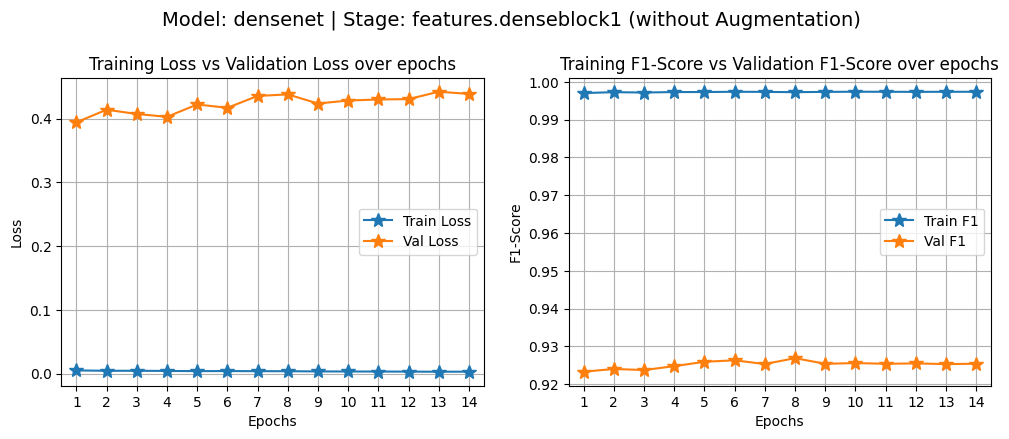

Stage:  83%|████████▎ | 5/6 [13:02<02:36, 156.53s/stage]


Training of stage "features.denseblock1" completed in 13.04 minutes.

No layers are frozen, all layers are trainable.

Loading best model from previous stage: features.denseblock1 for stage None
Starting stage 'None' from epoch 1 with LR = 1.00e-05
---------------------------------------------------------------------------------------------------------------------------------

*************************************************  Running epoch: 1 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:57<00:00,  1.16batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug/None_checkpoint_epoch_0.pt
Epoch 1 [None]: Train Loss = 0.0046 | Train F1 = 0.9969 | Val Loss = 0.4688 | Val F1 = 0.9239 | LR = 9.90e-06 | Time = 135.26s

*************************************************  Running epoch: 2 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:55<00:00,  1.18batch/s]


...

[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug/None_checkpoint_epoch_7.pt
Epoch 8 [None]: Train Loss = 0.0033 | Train F1 = 0.9973 | Val Loss = 0.4245 | Val F1 = 0.9258 | LR = 5.03e-06 | Time = 134.10s

*************************************************  Running epoch: 9 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:56<00:00,  1.18batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug/None_checkpoint_epoch_8.pt
Epoch 9 [None]: Train Loss = 0.0032 | Train F1 = 0.9974 | Val Loss = 0.4045 | Val F1 = 0.9262 | LR = 4.11e-06 | Time = 133.80s

*************************************************  Running epoch: 10 out of 15  ****************************************************


Evaluating: 100%|██████████| 66/66 [00:56<00:00,  1.17batch/s]


[DRIVE CHECKPOINT] Saved: /content/drive/MyDrive/hackathon_checkpoints/densenet_no_aug/None_checkpoint_epoch_9.pt
Epoch 10 [None]: Train Loss = 0.0032 | Train F1 = 0.9973 | Val Loss = 0.4309 | Val F1 = 0.9245 | LR = 3.25e-06 | Time = 134.60s
Early stopping triggered!

[EARLY STOP] Loading and saving best model from earlier epoch.
Best Stats: Val F1: 0.9268 | Val Loss: 0.3936
########################################################################################
Saved model to /content/drive/MyDrive/oct_models/densenet_no_aug/densenet_None_best.pth
########################################################################################
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Stopping early at epoch 10

The loss and training curves at stage None are:

Plot saved to: /content/drive/MyDrive/plots/densenet_no_aug/stage_full_training_not_aug.png


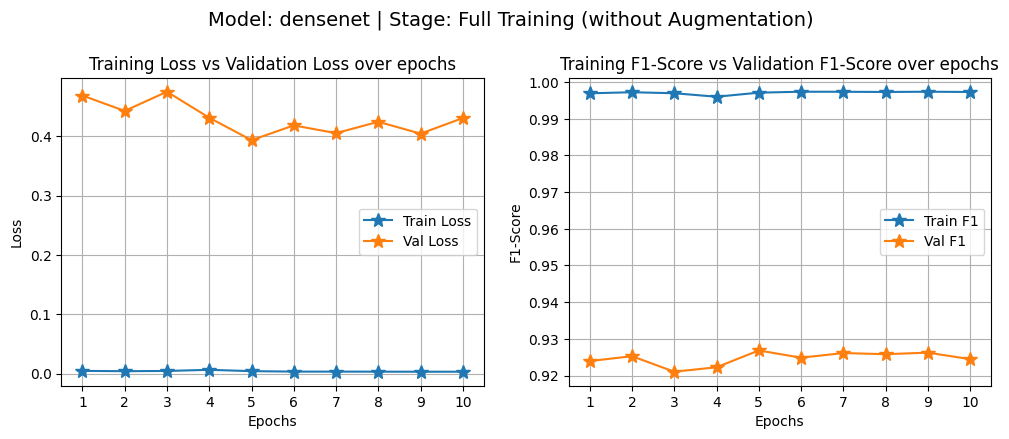

Stage: 100%|██████████| 6/6 [35:23<00:00, 353.89s/stage]


Training of stage "None" completed in 22.34 minutes.

#################################################################################################################################


In [ ]:
print("#" * 129)
print("Please wait until training the \"oct-classification model\" is done.")
prev_stage=None

for stage in tqdm(stages, desc='Stage', unit='stage', position=0, leave=True):
    lr = 1e-4  if stage in ['classifier', 'features.denseblock4', 'features.denseblock3'] else 1e-5 # initial learning rate
    # Check if stage is completed by finding if best model exists
    best_model_path = os.path.join(path_oct_models, f"densenet_{stage}_best.pth")
    if os.path.exists(best_model_path):
        print(f"[INFO] Best model for {stage} already exists. Skipping to next stage.")
        prev_stage = stage
        continue

    early_stopping = utils.Early_Stopping_densenet()

    # Freeze layers for the stage
    utils.freeze_first_n_layers(model, stage)

    # Setup optimizer & scheduler
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    # Load checkpoint if it exists
    (model, optimizer, scheduler, start_epoch,
     train_epoch_losses, train_epoch_f1s,
     val_epoch_losses, val_epoch_f1s,
     num_epochs_checkpoint, data_fraction_checkpoint) = utils.load_latest_checkpoint(model, optimizer, scheduler, stage, path=path_hackathon_checkpoints)

    if start_epoch == 0 and prev_stage is not None:
        current_prev_best_path = os.path.join(path_oct_models, f"densenet_{prev_stage}_best.pth")
        if os.path.exists(current_prev_best_path):
            print(f"Loading best model from previous stage: {prev_stage} for stage {stage}")
            model.load_state_dict(torch.load(current_prev_best_path, map_location=device))
        else:
            print(f"No best model found for previous stage: {prev_stage}, starting from current model weights.")

    resumed_lr = optimizer.param_groups[0]['lr']
    stage_start = time.time()
    print(f"Starting stage '{stage}' from epoch {start_epoch + 1} with LR = {resumed_lr:.2e}")
    print("-" * 129)

    for epoch in range(start_epoch, num_epochs):
        epoch_start = time.time()
        print("")
        print("*" * 49, f" Running epoch: {epoch + 1} out of {num_epochs} ", "*" * 52)

        # Train + Evaluate
        train_epoch_loss, train_epoch_f1 = utils.train_model(model, train_loader, criterion, optimizer, device)
        val_epoch_loss, val_epoch_f1 = utils.evaluate(model, val_loader, criterion, device)

        # Update LR
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Accumulate metrics
        train_epoch_losses.append(train_epoch_loss)
        train_epoch_f1s.append(train_epoch_f1)
        val_epoch_losses.append(val_epoch_loss)
        val_epoch_f1s.append(val_epoch_f1)

        # Save checkpoint
        utils.save_checkpoint(model, optimizer, scheduler, stage, epoch,
                        train_epoch_losses, train_epoch_f1s,
                        val_epoch_losses, val_epoch_f1s,
                        num_epochs=num_epochs,
                        data_fraction=1.0,
                        path=path_hackathon_checkpoints)

        epoch_time = time.time() - epoch_start
        print("=" * 129)
        print(
            f"Epoch {epoch + 1} [{stage}]: "
            f"Train Loss = {train_epoch_loss:.4f} | Train F1 = {train_epoch_f1:.4f} | "
            f"Val Loss = {val_epoch_loss:.4f} | Val F1 = {val_epoch_f1:.4f} | "
            f"LR = {current_lr:.2e} | Time = {epoch_time:.2f}s"
        )
        print("=" * 129)

        # Early stopping
        early_stopping(val_epoch_f1, val_epoch_loss, model)
        if early_stopping.early_stop:
            model.load_state_dict(early_stopping.best_state)
            best_model = copy.deepcopy(model)
            print(f"\n[EARLY STOP] Loading and saving best model from earlier epoch.")
            print(f"Best Stats: Val F1: {early_stopping.best_score:.4f} | Val Loss: {early_stopping.best_loss:.4f}")
            utils.save_best_model(best_model, "densenet", stage, path_to_models=path_oct_models)
            print("!" * 40)
            print(f"Stopping early at epoch {epoch + 1}")
            break

    # Save best model if early stop did not trigger
    if not early_stopping.early_stop:
        model.load_state_dict(early_stopping.best_state)
        best_model = copy.deepcopy(model)
        print(f"\n[TRAINING COMPLETE] Saving final best model.")
        print(f"Best Stats: Val F1: {early_stopping.best_score:.4f} | Val Loss: {early_stopping.best_loss:.4f}")
        utils.save_best_model(best_model, "densenet", stage, path_to_models=path_oct_models)

    # Plot curves using accumulated metrics (including resumed epochs)
    print(f"\nThe loss and training curves at stage {stage} are:\n")
    utils.loss_train_curve_plots(
        num_epochs=len(train_epoch_losses),
        train_epoch_losses=train_epoch_losses,
        train_epoch_f1s=train_epoch_f1s,
        val_epoch_losses=val_epoch_losses,
        val_epoch_f1s=val_epoch_f1s,
        save_plot=True,
        stage=stage,
        model_name='densenet',
        augmented=False,
        path_plots=path_plots
    )

    total_stage_time = time.time() - stage_start
    print(f"\nTraining of stage \"{stage}\" completed in {total_stage_time / 60:.2f} minutes.\n")
    prev_stage = stage
print("#" * 129)

Extracted 77 total epochs across 6 stages.
Best models identified at global epoch indices: [11, 26, 41, 47, 60, 71]


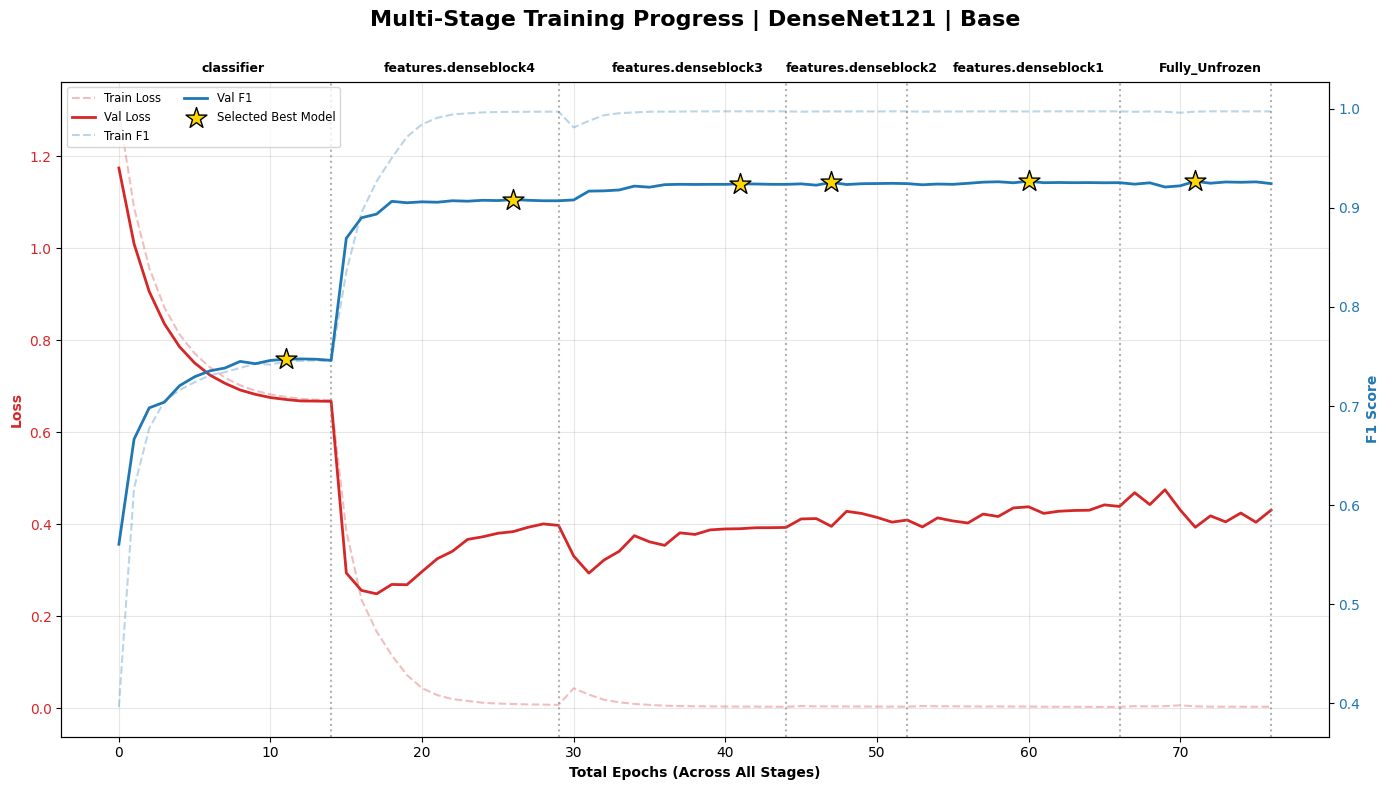

In [ ]:
# Extract all the data from checkpoints
metrics_dict = utils.extract_all_metrics(stages, path_hackathon_checkpoints)

# Check if data exists
if not metrics_dict['val_loss']:
    print("No metrics found. Check your stage names and checkpoint path.")
else:
    total_epochs = len(metrics_dict['val_loss'])
    print(f"Extracted {total_epochs} total epochs across {len(stages)} stages.")
    print(f"Best models identified at global epoch indices: {metrics_dict['best_indices']}")

    # Generate the visualization once for inspection
    utils.plot_multi_stage_metrics(
        metrics=metrics_dict,
        stages=stages,
        model_name='DenseNet121',
        is_augmented=False
    )
plt.show()

Plot saved to: /content/drive/MyDrive/plots/densenet_no_aug


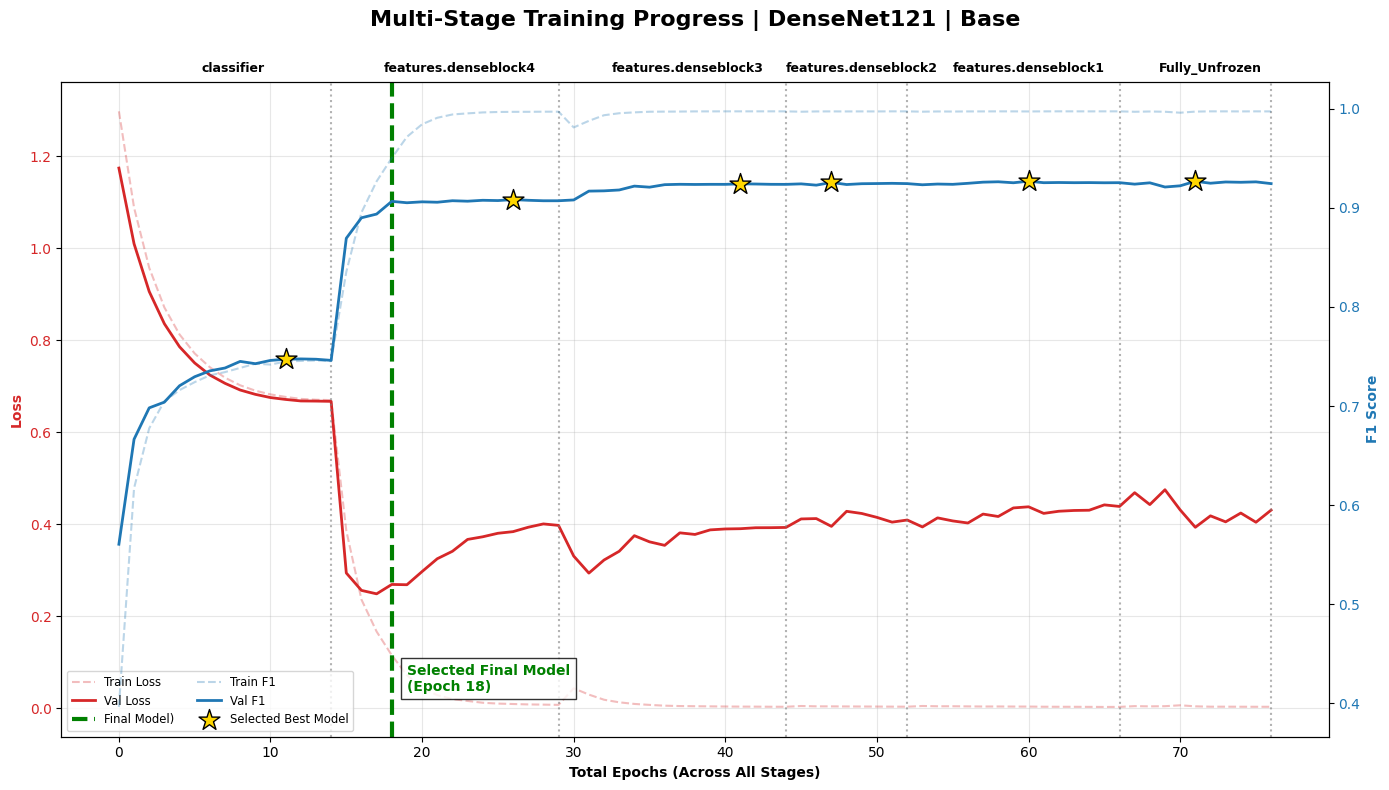

In [ ]:
#  Generate the plot again to show best model
utils.plot_multi_stage_metrics(
    metrics=metrics_dict,
    stages=stages,
    model_name='DenseNet121',
    is_augmented=False
)

target_epoch = 18
ax1 = plt.gcf().axes[0]  # Get the Loss axis
ax2 = plt.gcf().axes[1]  # Get the F1 axis

# Draw the selection line
line_selection = ax1.axvline(x=target_epoch, color='green', linestyle='--',
                             linewidth=3, label='Final Model)')

# Add the text annotation
ax1.text(target_epoch + 1, ax1.get_ylim()[0] + 0.1, 'Selected Final Model\n(Epoch 18)',
         color='green', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

# Gather all handles and labels from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

# Remove the old legend if it exists to prevent ghosting
if ax1.get_legend(): ax1.get_legend().remove()
if ax2.get_legend(): ax2.get_legend().remove()

# Create one final combined legend on ax1 or ax2
ax1.legend(h1 + h2, l1 + l2, loc='lower left', ncol=2, fontsize='small', frameon=True)

# Save and show
os.makedirs(path_plots, exist_ok=True)
full_path =  f"{path_plots}/Learning_Curves_Combined.png"
plt.savefig(full_path, bbox_inches='tight', dpi=300)
print(f"Plot saved to: {path_plots}")
plt.show()

In [ ]:
# Define paths
checkpoint_path = os.path.join(path_hackathon_checkpoints, "features.denseblock4_checkpoint_epoch_3.pt")
os.makedirs(path_final_models, exist_ok=True)
final_model_save_path = os.path.join(path_final_models, "densenet_base_final.pth")

if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location='cpu')

    model_state = checkpoint['model_state_dict']

    # Save as your final model file
    torch.save(model_state, final_model_save_path)

    print(f"Successfully extracted Epoch 18 from stage 'features.denseblock4'.")
    print(f"Final model saved to: {final_model_save_path}")
else:
    print(f"Error: Could not find the file at {checkpoint_path}")

Successfully extracted Epoch 18 from stage 'features.denseblock4'.
Final model saved to: /content/drive/MyDrive/Final_Models/densenet_base_final.pth
